In [2]:
import numpy as np
import matplotlib.pyplot as plt

from inspectre import Inspectre

In [3]:
a   = 0.5      # spin
p   = 10.0     # semilatus rectum
e   = 0.3      # eccentricity
x   = 1
mass = 1.0
err  = 1e-15

insp = Inspectre(
    spin=a, semilatus_rectum=p, eccentricity=e, x=x,
    mass=mass, err=err, orbit="equatorial")

Tr = 2.0 * np.pi / insp.omega_r
Vr = insp.mino_period_r

In [4]:
lam_values = np.linspace(0,Vr,512)
psi = np.array([insp.psi_from_lambda(l) for l in lam_values])
phi = np.array([insp.phi_from_lambda(l) for l in lam_values])

In [5]:
m, n = 5, -5              # azimuthal / radial mode
r_field, theta_field = 10.0, np.pi/2 - 0.001   # field point (near equator)

In [6]:
traj_dat = np.array([
    [insp.t_from_lambda(l), insp.r_from_lambda(l), insp.theta_from_lambda(l), insp.phi_from_lambda(l), insp.four_velocity_equatorial(l)] for l in lam_values]
    )
t, r, th, ph, ur = traj_dat.T

ev = []
# Fast C: evaluate directly at lambda
for l in lam_values:
    ev.append(insp.eval_at_lambda_fast(m, l, r_field, theta_field)[0])

phi_r = t * insp.omega_r

ev = np.array(ev)
packed = np.array([lam_values, ev.T[0], ev.T[1]]).T

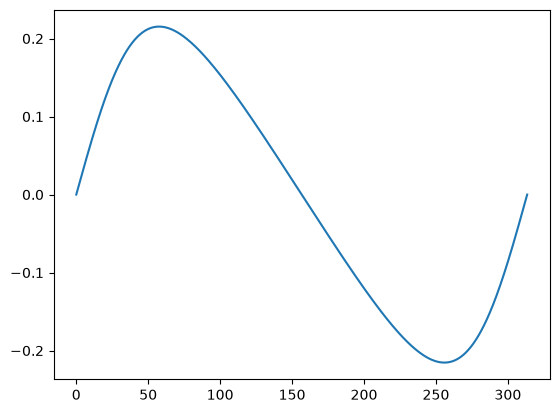

In [7]:
plt.plot(t, ur)

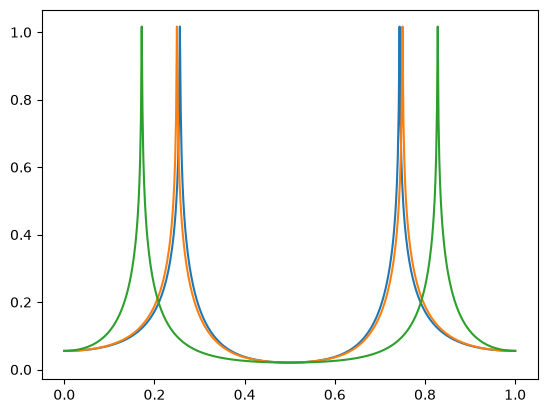

In [14]:
mag = np.abs(packed.T[1]+1j*packed.T[2])
tscale = t / (ur + 1e-12)
plt.plot(packed.T[0]/packed.T[0][-1], mag)
plt.plot(psi/psi[-1], mag)
plt.plot(t/t[-1], mag)

plt.show()